# SupplyPrescript
## Notebook 6: Hyperparameter Tuning & Prescriptive Analytics

### Objective
This notebook extends the predictive model developed in Notebook 5. It first tunes the XGBoost classifier using `GridSearchCV` and then uses the tuned model's shipment-delay probability as an input to a prescriptive optimization engine built with PuLP.

### Main Tasks
- Load processed training and testing datasets.
- Tune XGBoost using GridSearchCV.
- Evaluate the tuned model.
- Compare original and tuned XGBoost.
- Save the tuned model.
- Build a PuLP optimization engine.
- Define business actions, costs, and constraints.
- Generate an optimal recommendation.
- Save optimization results.


## 6.1 Import Required Libraries


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier
import joblib
#from pulp import *


## 6.2 Load Processed Training and Testing Data


In [2]:
X_train = pd.read_csv("../data/Processed/X_train.csv")
X_test = pd.read_csv("../data/Processed/X_test.csv")

y_train = pd.read_csv("../data/Processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/Processed/y_test.csv").squeeze()

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)


X_train shape: (144415, 33)
X_test shape : (36104, 33)
y_train shape: (144415,)
y_test shape : (36104,)


## 6.3 Create the Base XGBoost Model

A base XGBoost classifier is created before systematic hyperparameter tuning.


In [3]:
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

print(xgb_model)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)


## 6.4 Define the Hyperparameter Grid

GridSearchCV will test combinations of selected XGBoost parameters. F1-score is used because the project needs a balance between identifying risky shipments and avoiding excessive false alarms.


In [4]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0]
}

total_combinations = (
    len(param_grid["n_estimators"])
    * len(param_grid["max_depth"])
    * len(param_grid["learning_rate"])
    * len(param_grid["subsample"])
)

print("Parameter combinations:", total_combinations)
print("Models evaluated with 3-fold CV:", total_combinations * 3)


Parameter combinations: 36
Models evaluated with 3-fold CV: 108


## 6.5 Run GridSearchCV


In [5]:
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)


Fitting 3 folds for each of 36 candidates, totalling 108 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.1], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], 'subsample': [0.8, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candid

## 6.6 Best Hyperparameters


In [6]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(grid_search.best_score_)


Best Parameters:
{'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'subsample': 1.0}

Best Cross-Validation F1 Score:
0.9700644455722419


## 6.7 Obtain the Tuned XGBoost Model


In [7]:
tuned_xgb = grid_search.best_estimator_

print(tuned_xgb)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)


## 6.8 Evaluate the Tuned Model


In [8]:
tuned_pred = tuned_xgb.predict(X_test)
tuned_prob = tuned_xgb.predict_proba(X_test)[:, 1]

tuned_accuracy = accuracy_score(y_test, tuned_pred)
tuned_precision = precision_score(y_test, tuned_pred)
tuned_recall = recall_score(y_test, tuned_pred)
tuned_f1 = f1_score(y_test, tuned_pred)
tuned_auc = roc_auc_score(y_test, tuned_prob)

print("Tuned XGBoost Performance")
print("-------------------------")
print("Accuracy :", tuned_accuracy)
print("Precision:", tuned_precision)
print("Recall   :", tuned_recall)
print("F1 Score :", tuned_f1)
print("ROC-AUC  :", tuned_auc)


Tuned XGBoost Performance
-------------------------
Accuracy : 0.9685907378683802
Precision: 0.9567750146857255
Recall   : 0.9873206708425945
F1 Score : 0.9718078758949881
ROC-AUC  : 0.9961252757647255


In [9]:
print(classification_report(y_test, tuned_pred))


              precision    recall  f1-score   support

           0       0.98      0.95      0.96     16308
           1       0.96      0.99      0.97     19796

    accuracy                           0.97     36104
   macro avg       0.97      0.97      0.97     36104
weighted avg       0.97      0.97      0.97     36104



## 6.9 Confusion Matrix of Tuned XGBoost


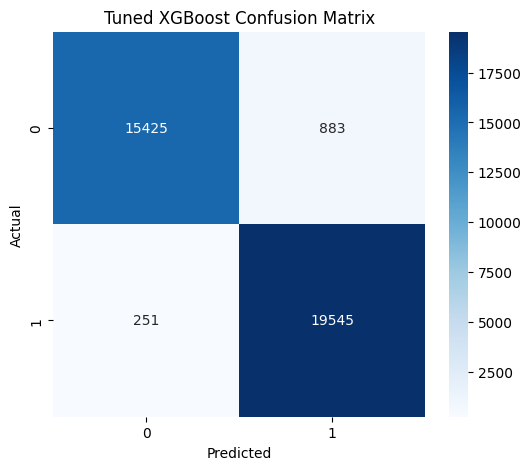

In [10]:
cm = confusion_matrix(y_test, tuned_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Tuned XGBoost Confusion Matrix")
plt.show()


## 6.10 Compare Original and Tuned XGBoost

Notebook 5 saved the original XGBoost model as `Best_model.pkl`. This comparison checks whether hyperparameter tuning improved performance.


In [11]:
original_xgb = joblib.load("../models/Best_model.pkl")

original_pred = original_xgb.predict(X_test)
original_prob = original_xgb.predict_proba(X_test)[:, 1]

original_accuracy = accuracy_score(y_test, original_pred)
original_precision = precision_score(y_test, original_pred)
original_recall = recall_score(y_test, original_pred)
original_f1 = f1_score(y_test, original_pred)
original_auc = roc_auc_score(y_test, original_prob)

comparison = pd.DataFrame({
    "Model": ["Original XGBoost", "Tuned XGBoost"],
    "Accuracy": [original_accuracy, tuned_accuracy],
    "Precision": [original_precision, tuned_precision],
    "Recall": [original_recall, tuned_recall],
    "F1 Score": [original_f1, tuned_f1],
    "ROC-AUC": [original_auc, tuned_auc]
})

comparison


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Original XGBoost,0.964935,0.952923,0.984694,0.968548,0.995026
1,Tuned XGBoost,0.968591,0.956775,0.987321,0.971808,0.996125


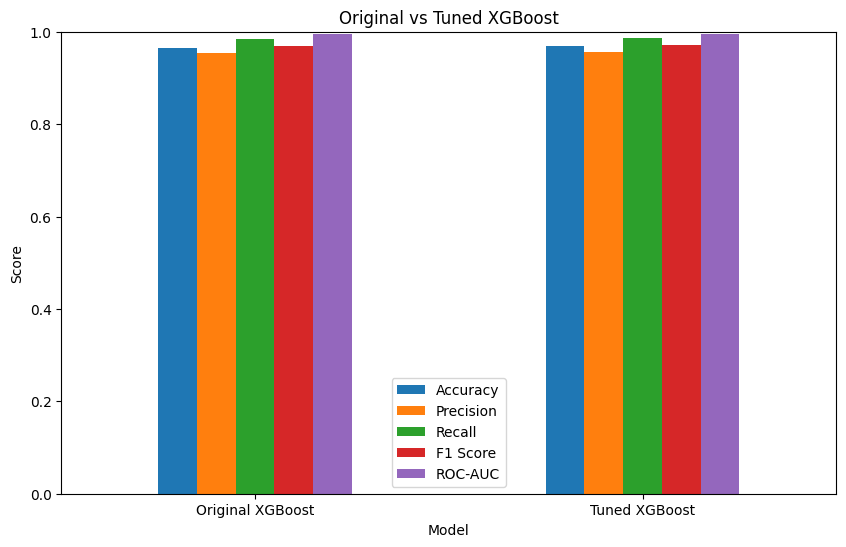

In [12]:
comparison.set_index("Model").plot(kind="bar", figsize=(10, 6))
plt.title("Original vs Tuned XGBoost")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()


## 6.11 Save the Tuned Model


In [13]:
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(
    tuned_xgb,
    "../models/Tuned_XGBoost.pkl"
)

print("Tuned XGBoost saved successfully!")


Tuned XGBoost saved successfully!


# PART B — PRESCRIPTIVE ANALYTICS

The predictive model identifies shipments at risk of delay. The next step is to recommend an operational action.

The initial optimization prototype uses business assumptions for action costs and expected delay impact. These values demonstrate the optimization framework and should not be presented as observed values from the DataCo dataset.


## 6.12 Example High-Risk Shipment

The tuned model can produce a delay probability for a shipment. For demonstration, the optimization engine is tested with a high-risk probability.


In [14]:
example_delay_probability = 0.82

print("Example Delay Probability:", example_delay_probability)
print(
    "Example Risk Level: High Risk"
    if example_delay_probability >= 0.70
    else "Example Risk Level: Lower Risk"
)


Example Delay Probability: 0.82
Example Risk Level: High Risk


## 6.13 Define Available Business Actions

The prototype considers four possible decisions:
1. Continue with standard shipping.
2. Upgrade to air freight.
3. Use an alternative supplier.
4. Delay the product launch.

The action costs and delay impacts below are demonstration assumptions.


In [15]:
action_costs = {
    "standard_shipping": 0,
    "air_freight": 15000,
    "alternative_supplier": 10000,
    "delay_launch": 5000
}

delay_impact = {
    "standard_shipping": example_delay_probability,
    "air_freight": 0.20,
    "alternative_supplier": 0.30,
    "delay_launch": 1.00
}

actions = pd.DataFrame({
    "Action": list(action_costs.keys()),
    "Cost": list(action_costs.values()),
    "Expected_Delay_Risk": [
        delay_impact[action] for action in action_costs
    ]
})

actions


,Action,Cost,Expected_Delay_Risk
0,standard_shipping,0,0.82
1,air_freight,15000,0.20
2,alternative_supplier,10000,0.30
3,delay_launch,5000,1.00


In [17]:
import sys
!{sys.executable} -m pip install pulp

   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   - -------------------------------------- 0.5/16.4 MB 1.5 MB/s eta 0:00:11
   - -------------------------------------- 0.8/16.4 MB 1.5 MB/s eta 0:00:11
   -- ------------------------------------- 1.0/16.4 MB 1.5 MB/s eta 0:00:11
   --- ------------------------------------ 1.6/16.4 MB 1.6 MB/s eta 0:00:10
   ---- ----------------------------------- 1.8/16.4 MB 1.7 MB/s eta 0:00:09
   ----- ---------------------------------- 2.4/16.4 MB 1.7 MB/s eta 0:00:09
   ------ --------------------------------- 2.6/16.4 MB 1.8 MB/s eta 0:00:08
   ------- -------------------------------- 3.1/16.4 MB 1.8 MB/s eta 0:00:08
   -------- ------------------------------- 3.4/16.4 MB 1.8 MB/s eta 0:00:08
   --------- ------------------------------ 3.9/16.4 MB 1.8 MB/s eta 0:00:07
   ---------- ------


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
from pulp import *

## 6.14 Define Decision Variables

Each action is represented by a binary decision variable:

`0` = action is not selected

`1` = action is selected


In [19]:
decision_vars = {
    "standard_shipping": LpVariable(
        "standard_shipping", cat="Binary"
    ),
    "air_freight": LpVariable(
        "air_freight", cat="Binary"
    ),
    "alternative_supplier": LpVariable(
        "alternative_supplier", cat="Binary"
    ),
    "delay_launch": LpVariable(
        "delay_launch", cat="Binary"
    )
}

decision_vars


{'standard_shipping': standard_shipping,
 'air_freight': air_freight,
 'alternative_supplier': alternative_supplier,
 'delay_launch': delay_launch}

## 6.15 Create the Optimization Problem


In [20]:
problem = LpProblem(
    "SupplyPrescript_Optimization",
    LpMinimize
)

delay_penalty_weight = 10000

problem += lpSum(
    decision_vars[action] * (
        action_costs[action]
        + delay_impact[action] * delay_penalty_weight
    )
    for action in decision_vars
)


## 6.16 Add Business Constraints


In [21]:
budget = 20000

# Exactly one action must be selected
problem += lpSum(decision_vars.values()) == 1

# Additional action cost cannot exceed available budget
problem += lpSum(
    decision_vars[action] * action_costs[action]
    for action in decision_vars
) <= budget

print("Budget constraint:", budget)


Budget constraint: 20000


## 6.17 Solve the Optimization Problem


In [22]:
problem.solve(PULP_CBC_CMD(msg=False))

print("Optimization Status:", LpStatus[problem.status])
print("Objective Value:", value(problem.objective))


Optimization Status: Optimal
Objective Value: 8200.0


## 6.18 Display the Recommended Action


In [23]:
recommended_action = None

for action, variable in decision_vars.items():
    if variable.value() == 1:
        recommended_action = action
        break

print("Recommended Action:", recommended_action)
print("Additional Cost:", action_costs[recommended_action])
print("Expected Delay Risk:", delay_impact[recommended_action])


Recommended Action: standard_shipping
Additional Cost: 0
Expected Delay Risk: 0.82


## 6.19 Build a Reusable Optimization Function

The optimization logic is converted into a function so that the same engine can later be called from the FastAPI backend.


In [24]:
def optimize_shipment(delay_probability, budget=20000):
    """Return the best feasible operational action for a shipment."""

    decision_vars = {
        "standard_shipping": LpVariable(
            "standard_shipping", cat="Binary"
        ),
        "air_freight": LpVariable(
            "air_freight", cat="Binary"
        ),
        "alternative_supplier": LpVariable(
            "alternative_supplier", cat="Binary"
        ),
        "delay_launch": LpVariable(
            "delay_launch", cat="Binary"
        )
    }

    action_costs = {
        "standard_shipping": 0,
        "air_freight": 15000,
        "alternative_supplier": 10000,
        "delay_launch": 5000
    }

    delay_impact = {
        "standard_shipping": delay_probability,
        "air_freight": 0.20,
        "alternative_supplier": 0.30,
        "delay_launch": 1.00
    }

    problem = LpProblem(
        "SupplyPrescript_Optimization",
        LpMinimize
    )

    delay_penalty_weight = 10000

    problem += lpSum(
        decision_vars[action] * (
            action_costs[action]
            + delay_impact[action] * delay_penalty_weight
        )
        for action in decision_vars
    )

    problem += lpSum(decision_vars.values()) == 1

    problem += lpSum(
        decision_vars[action] * action_costs[action]
        for action in decision_vars
    ) <= budget

    problem.solve(PULP_CBC_CMD(msg=False))

    if LpStatus[problem.status] != "Optimal":
        return {
            "status": LpStatus[problem.status],
            "recommended_action": None,
            "additional_cost": None,
            "expected_delay_risk": None
        }

    for action, variable in decision_vars.items():
        if variable.value() == 1:
            return {
                "status": LpStatus[problem.status],
                "recommended_action": action,
                "additional_cost": action_costs[action],
                "expected_delay_risk": delay_impact[action]
            }


## 6.20 Test the Optimization Engine


In [25]:
result = optimize_shipment(
    delay_probability=0.82,
    budget=20000
)

print(result)


{'status': 'Optimal', 'recommended_action': 'standard_shipping', 'additional_cost': 0, 'expected_delay_risk': 0.82}


## 6.21 Test Multiple Risk Levels

Testing several probabilities demonstrates how the recommendation changes as predicted risk changes.


In [26]:
test_probabilities = [0.20, 0.50, 0.80, 0.95]
optimization_results = []

for probability in test_probabilities:
    result = optimize_shipment(
        delay_probability=probability,
        budget=20000
    )

    result["delay_probability"] = probability
    optimization_results.append(result)

optimization_df = pd.DataFrame(optimization_results)
optimization_df


,status,recommended_action,additional_cost,expected_delay_risk,delay_probability
0,Optimal,standard_shipping,0,0.20,0.20
1,Optimal,standard_shipping,0,0.50,0.50
2,Optimal,standard_shipping,0,0.80,0.80
3,Optimal,standard_shipping,0,0.95,0.95


## 6.22 Save Optimization Results


In [27]:
os.makedirs("../data/Processed", exist_ok=True)

optimization_df.to_csv(
    "../data/processed/optimization_results.csv",
    index=False
)

print("Optimization results saved successfully!")


Optimization results saved successfully!


# Summary

Notebook 6 extends SupplyPrescript in two stages.

First, XGBoost hyperparameters are optimized using GridSearchCV. The tuned model is evaluated against the original XGBoost model and saved for downstream use.

Second, the tuned model's delay probability is connected to a prescriptive optimization engine implemented using PuLP. The engine evaluates alternative operational actions under cost and decision constraints and recommends the best feasible action.

### Outputs
- Best XGBoost hyperparameters
- Tuned XGBoost performance metrics
- Original vs tuned model comparison
- `Tuned_XGBoost.pkl`
- Optimal operational action
- Optimization results CSV

### Transition to the Next Stage

The next stage will convert the predictive and prescriptive logic into reusable backend functionality so that a user can submit shipment information and receive a delay-risk prediction together with an operational recommendation.
